In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os, tqdm, glob, hdf5plugin
# os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.49'
os.environ["JAX_PLATFORM_NAME"] = "cpu"
import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import jax_cosmo as jc

import jaxpm
from jaxpm.painting import cic_paint, cic_read, compensate_cic
from jaxpm.utils import power_spectrum, cross_correlation_coefficients
from jaxpm import camels, plotting
jax.devices()

[CpuDevice(id=0)]

In [3]:
mesh_per_dim = 64
# mesh_per_dim = 256
mesh_shape = [mesh_per_dim] * 3

# CAMELS

In [4]:
CAMELS = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims"
# CODE = "IllustrisTNG"
# CODE = "SIMBA"
CODE = "Astrid"
SIMSET = "CV/CV_0"

# my pipeline

In [5]:
# i_snapshots = range(1, 33+4, 4)
i_snapshots = range(1, 33+8, 8)
# i_snapshots = [0, -1]

# parts_per_dim = None
parts_per_dim = mesh_per_dim

# nbody
n_FILES = os.path.join(CAMELS, CODE + "_DM", SIMSET)
nbody_dict = camels.load_CV_snapshots(
    n_FILES,
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=i_snapshots,
    return_hydro=False,
)

scales = nbody_dict["scales"]
cosmo = nbody_dict["cosmo"]
n_dm_poss = nbody_dict["dm_poss"]
n_dm_masss = nbody_dict["dm_masss"]

h_FILES = os.path.join(CAMELS, CODE, SIMSET)
hydro_dict = camels.load_CV_snapshots(
    h_FILES,
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=i_snapshots,
    return_hydro=True,
)

h_dm_poss = hydro_dict["dm_poss"]
h_dm_masss = hydro_dict["dm_masss"]
h_gas_poss = hydro_dict["gas_poss"]
h_gas_masss = hydro_dict["gas_masss"]

Using snapshots ['/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/Astrid_DM/CV/CV_0/snapshot_002.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/Astrid_DM/CV/CV_0/snapshot_018.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/Astrid_DM/CV/CV_0/snapshot_034.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/Astrid_DM/CV/CV_0/snapshot_050.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/Astrid_DM/CV/CV_0/snapshot_066.hdf5']
Selecting 262144 dark matter (deterministic)


loading snapshots: 100%|██████████| 5/5 [00:14<00:00,  2.84s/it]


Using snapshots ['/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/Astrid/CV/CV_0/snapshot_002.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/Astrid/CV/CV_0/snapshot_018.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/Astrid/CV/CV_0/snapshot_034.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/Astrid/CV/CV_0/snapshot_050.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/Astrid/CV/CV_0/snapshot_066.hdf5']
Selecting 262144 dark matter (deterministic)
Selecting 262144 gas particles (random)


finding unique gas particle indices: 100%|██████████| 5/5 [00:28<00:00,  5.70s/it]


There are 16726641 (99.70%) gas particles that exist in all snapshots


loading snapshots: 100%|██████████| 5/5 [01:17<00:00, 15.51s/it]


In [6]:
for i in range(len(h_gas_poss)):
    print(h_gas_poss[i].shape)

(262144, 3)
(262144, 3)
(262144, 3)
(262144, 3)
(262144, 3)


# total matter

In [7]:
# per-particle weighting

vcic_paint = jax.vmap(cic_paint, in_axes=(None,0,0))

n_rho_dm = vcic_paint(jnp.zeros(mesh_shape), n_dm_poss, n_dm_masss)
n_rho_tot = n_rho_dm

h_rho_dm = vcic_paint(jnp.zeros(mesh_shape), h_dm_poss, h_dm_masss)
h_rho_gas = vcic_paint(jnp.zeros(mesh_shape), h_gas_poss, h_gas_masss)
h_rho_tot = h_rho_dm + h_rho_gas

In [8]:
# constant weighting

# vcic_paint = jax.vmap(cic_paint, in_axes=(None,0,None))

# n_rho_dm = vcic_paint(jnp.zeros(mesh_shape), n_dm_poss, 1)
# n_rho_tot = n_rho_dm

# h_rho_dm = vcic_paint(jnp.zeros(mesh_shape), h_dm_poss, cosmo.Omega_c / (cosmo.Omega_c + cosmo.Omega_b))
# h_rho_gas = vcic_paint(jnp.zeros(mesh_shape), h_gas_poss, cosmo.Omega_b / (cosmo.Omega_c + cosmo.Omega_b))
# h_rho_tot = h_rho_dm + h_rho_gas

In [9]:
# variable number of gas particles

# n_rho_tot = []
# h_rho_tot = []
# for i in range(len(scales)):
#     n_rho_dm = cic_paint(jnp.zeros(mesh_shape), n_dm_poss[i], n_dm_masss[i])
#     n_rho_tot.append(n_rho_dm)
    
#     h_rho_dm = cic_paint(jnp.zeros(mesh_shape), h_dm_poss[i], h_dm_masss[i])
#     h_rho_gas = cic_paint(jnp.zeros(mesh_shape), h_gas_poss[i], h_gas_masss[i])
#     h_rho_tot.append(h_rho_dm + h_rho_gas)
    
# n_rho_tot = jnp.stack(n_rho_tot, axis=0)
# h_rho_tot = jnp.stack(h_rho_tot, axis=0)

In [10]:
# simplified plot for debugging

# box_size = 25.0

# def pk_wrapper(field):
#     k, pk = power_spectrum(
#         compensate_cic(field),
#         boxsize=np.array([box_size] * 3),
#         kmin=np.pi / box_size,
#         dk=2 * np.pi / box_size,
#     )
#     return k, pk

# i = -1
# k, n_pk_tot = pk_wrapper(n_rho_tot[-1])
# k, h_pk_tot = pk_wrapper(h_rho_tot[-1])

# fig, ax = plt.subplots(nrows=2, sharex=True, figsize=(4, 2*4))

# ax[0].plot(k, n_pk_tot, label="nbody")
# ax[0].plot(k, h_pk_tot, label="hydro")

# ax[0].set(xscale="log", yscale="log", xlabel=r"$k$ [$h \ \mathrm{Mpc}^{-1}$]", ylabel=r"$P(k)$")
# ax[0].legend()

# ax[1].plot(k, h_pk_tot/n_pk_tot - 1, label="nbody")
# ax[1].set(xscale="log", yscale="linear", xlabel=r"$k$ [$h \ \mathrm{Mpc}^{-1}$]", ylabel=r"$P_\text{hydro}(k)/P_\text{nbody}(k) - 1$")

# fig.suptitle("total matter")

100%|██████████| 5/5 [00:02<00:00,  2.47it/s]


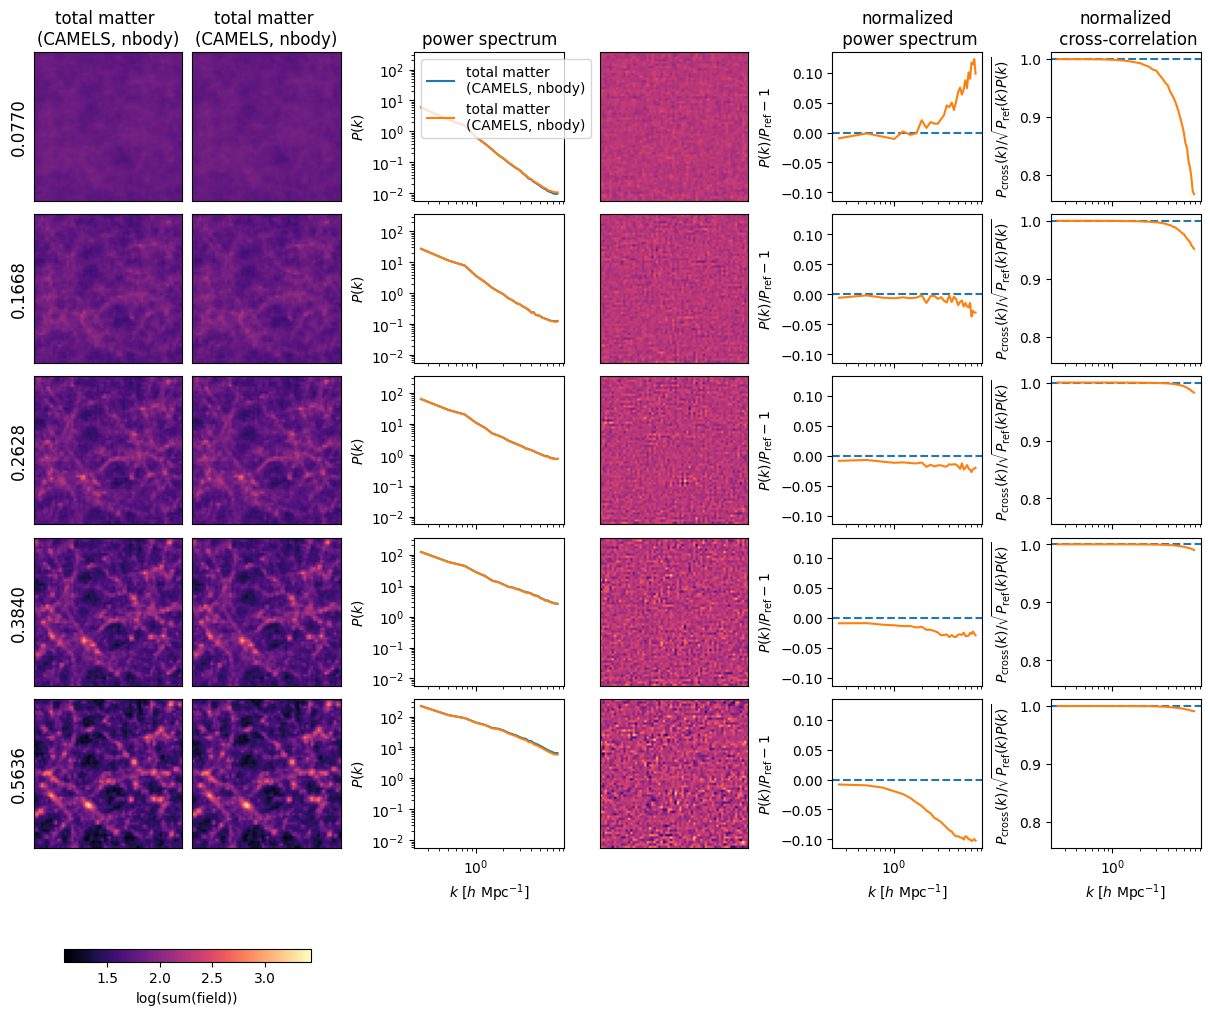

In [11]:
plotting.compare_field_evolution(
    scales,
    jnp.stack([n_rho_tot, h_rho_tot], axis=0),
    include_pk=True,
    include_reference=True,
    # values
    shared_colorbar=True,
    # cosmetics
    title=None,
    col_titles=["total matter \n(CAMELS, nbody)", "total matter \n(CAMELS, nbody)"],
)

# gas

In [12]:
vcic_paint = jax.vmap(cic_paint, in_axes=(None,0,0))
h_rho_gas = vcic_paint(jnp.zeros(mesh_shape), h_gas_poss, h_gas_masss)

vcic_paint = jax.vmap(cic_paint, in_axes=(None,0,None))
h_rho_gas_uniform = vcic_paint(jnp.zeros(mesh_shape), h_gas_poss, cosmo.Omega_b / (cosmo.Omega_c + cosmo.Omega_b))

100%|██████████| 5/5 [00:01<00:00,  2.81it/s]


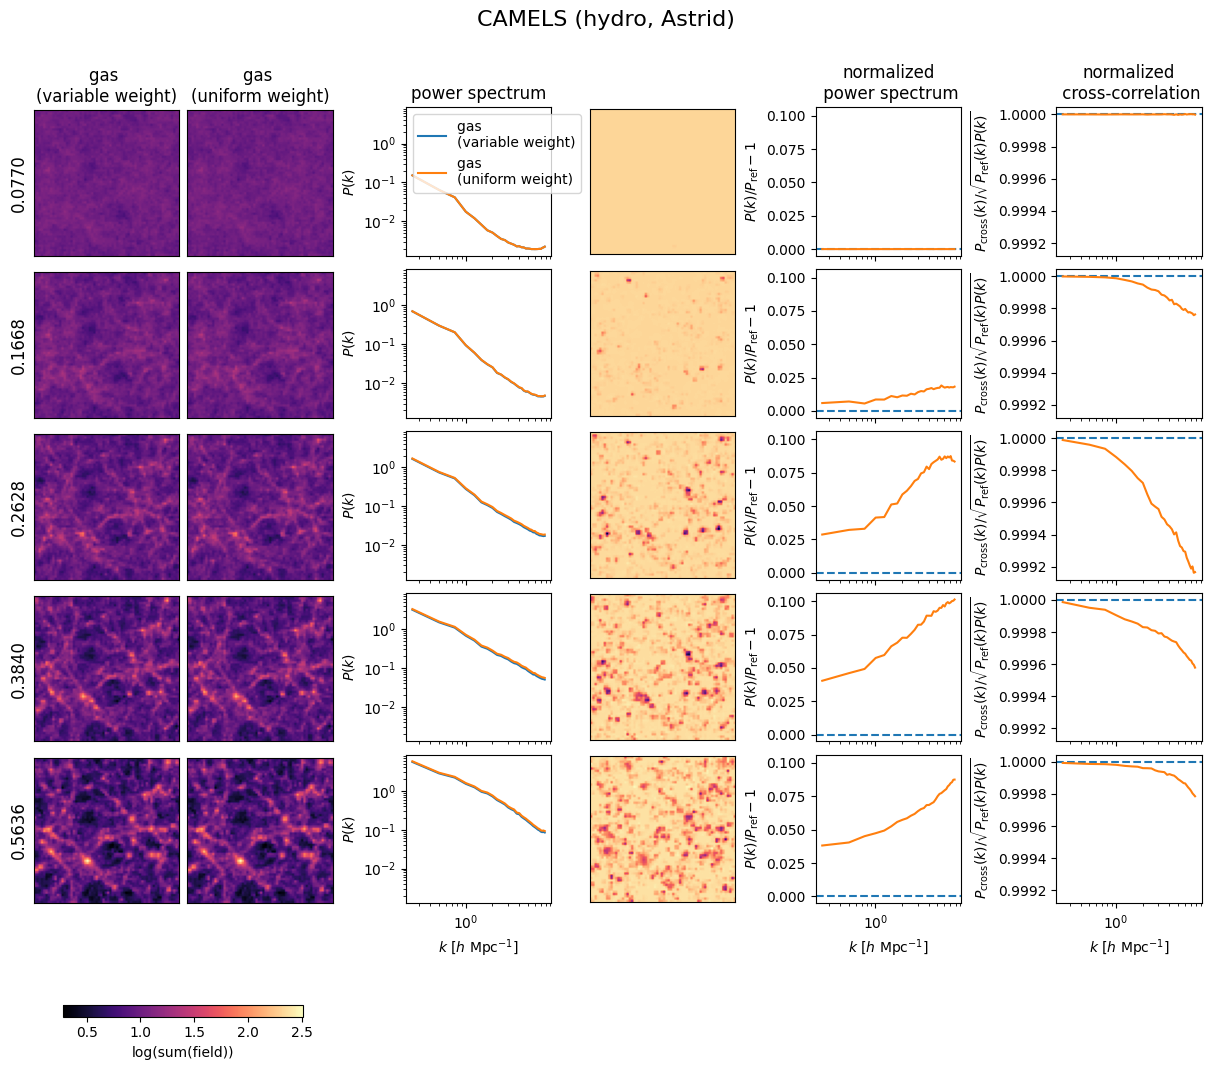

In [13]:
plotting.compare_field_evolution(
    scales,
    jnp.stack([h_rho_gas, h_rho_gas_uniform], axis=0),
    include_pk=True,
    include_reference=True,
    # values
    shared_colorbar=True,
    # cosmetics
    title=f"CAMELS (hydro, {CODE})",
    col_titles=["gas \n(variable weight)", "gas \n(uniform weight)"],
)